In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import csv
from collections import defaultdict

def wrightfishersampling(N: int, K: int) -> tuple[bool, int, list[list[int]]]:
    if N <= 0: 
        raise ValueError("Population number must be greater than zero.")
    if K < 0: 
        raise ValueError("Number of alleles cannot be negative.")
    if K > N: 
        raise ValueError("K cannot be greater than the total alleles.")
    
    history = []
    t = 0 
    current_K = K 

    while 0 < current_K < N: 
        p = current_K / N 
        history.append([t, current_K])
        
        current_K = int(np.random.binomial(n=N, p=p)) 
        t += 1 
    
    history.append([t, current_K]) 
    fixed = (current_K == N) 

    return fixed, t, history

def run_multiple_simulations(N: int, K: int, num_simulations: int) -> list[dict]: 
    all_simulation_data = []
    for i in range(num_simulations):
        fixed, final_t, history = wrightfishersampling(N, K)
        all_simulation_data.append({
            "fixed": fixed, 
            "final_generations": final_t,
            "generations": [step[0] for step in history], 
            "counts": [step[1] for step in history],
            "frequencies": [step[1] / N for step in history],
        })

        # Print progress every 100 runs
        run_number = i + 1
        if run_number % 100 == 0:
            print(f"Run {run_number} of {num_simulations} is done.")

    return all_simulation_data

def plot_allele_frequency_paths(simulation_results: list[dict], N: int, K: int): 
    """Plots the individual trajectories of allele frequencies over generations."""
    plt.figure(figsize=(10, 6))
    
    fixation_count = 0
    extinction_count = 0
    fixation_times = []
    extinction_times = []

    for run in simulation_results:
        if run["fixed"]:
            color = 'green'
            fixation_count += 1
            label = 'Fixed' if fixation_count == 1 else ""
            fixation_times.append(run["final_generations"])
        else:
            color = 'red'
            extinction_count += 1
            label = 'Extinct' if extinction_count == 1 else ""
            extinction_times.append(run["final_generations"])

        plt.plot(run["generations"], run["frequencies"], color=color, alpha=0.25, linewidth=1.0, label=label)

    # Calculate average generation times
    avg_fixation_time = np.mean(fixation_times) if fixation_times else 0
    avg_extinction_time = np.mean(extinction_times) if extinction_times else 0
    
    print("\n--- Simulation Metrics ---")
    print(f"Average generation time for Fixed alleles: {avg_fixation_time:.2f} generations")
    print(f"Average generation time for Extinct alleles: {avg_extinction_time:.2f} generations")
    print(f"Total Fixed: {fixation_count} | Total Extinct: {extinction_count}")
    print("--------------------------")

    # Layout configurations
    initial_freq = K / N
    plt.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='Fixation (p=1.0)')
    plt.axhline(y=0.0, color='black', linestyle=':', alpha=0.5, label='Extinction (p=0.0)')
    plt.axhline(y=initial_freq, color='blue', linestyle='--', alpha=0.5, label=f'Initial Freq (p={initial_freq:.2f})')

    plt.title(f"Wright-Fisher Model: Allele Frequency Paths (N={N})\nFixed: {fixation_count} | Extinct: {extinction_count}", fontsize=12)
    plt.xlabel("Generation (Time)", fontsize=11)
    plt.ylabel("Allele Frequency (p)", fontsize=11)
    plt.ylim(-0.05, 1.05)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()

def plot_observed_vs_expected_variance(simulation_results: list[dict], N: int):

    transitions = defaultdict(list)
    
    for run in simulation_results:
        counts = run["counts"]
        for t in range(len(counts) - 1):
            k_current = counts[t]
            k_next = counts[t + 1]
            freq_next = k_next / N
            transitions[k_current].append(freq_next)
            
    observed_counts = []
    observed_variances = []
    
    # Require at least 2 samples to compute a mathematical variance
    MIN_SAMPLES = 2 
    
    for k, next_freqs in transitions.items():
        if len(next_freqs) >= MIN_SAMPLES:
            observed_counts.append(k)
            observed_variances.append(np.var(next_freqs))
            
    observed_counts = np.array(observed_counts)
    observed_variances = np.array(observed_variances)
    sort_idx = np.argsort(observed_counts)
    
    observed_counts = observed_counts[sort_idx]
    observed_variances = observed_variances[sort_idx]
    observed_frequencies = observed_counts / N

    # Theoretical curve calculation
    expected_frequencies = np.linspace(0, 1, 500) 
    expected_variances = (expected_frequencies * (1 - expected_frequencies)) / N

    plt.figure(figsize=(10, 6))
    
    # Plot expected curve
    plt.plot(expected_frequencies, expected_variances, color='black', linestyle='--', 
             linewidth=2, label=r"Expected Variance: $\frac{x(1-x)}{N}$")
    
    # Plot empirical data
    plt.plot(observed_frequencies, observed_variances, color='crimson', linestyle='-', 
             linewidth=1.5, marker='o', markersize=3, alpha=0.8, label="Observed Variance")

    plt.title(f"Wright-Fisher Model: Observed vs. Expected Variance (N={N})", fontsize=12)
    plt.xlabel("Allele Frequency (x = k/N)", fontsize=11)
    plt.ylabel("Variance of Frequency in Next Generation", fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()

def export_to_csv(simulation_results: list[dict], filename: str = "wright_fisher_results.csv"):
    print(f"Exporting data to {filename}...")
    headers = ["Simulation_ID", "Is_Fixed", "Total_Generations", "Generation", "Allele_Frequency"]
    
    with open(filename, mode="w", newline="", encoding="utf-8-sig") as il:
        writer = csv.writer(il)
        writer.writerow(headers)
        for sim_id, run in enumerate(simulation_results, start=1):
            is_fixed = run["fixed"]
            total_gens = run["final_generations"]
            rows = (
                [sim_id, is_fixed, total_gens, gen, freq]
                for gen, freq in zip(run["generations"], run["frequencies"])
            )
            writer.writerows(rows)
    print("Export complete")
 

Run 100 of 1000 is done.
Run 200 of 1000 is done.
Run 300 of 1000 is done.
Run 400 of 1000 is done.
Run 500 of 1000 is done.
Run 600 of 1000 is done.
Run 700 of 1000 is done.
Run 800 of 1000 is done.
Run 900 of 1000 is done.
Run 1000 of 1000 is done.

--- Simulation Metrics ---
Average generation time for Fixed alleles: 1421.96 generations
Average generation time for Extinct alleles: 1332.12 generations
Total Fixed: 498 | Total Extinct: 502
--------------------------


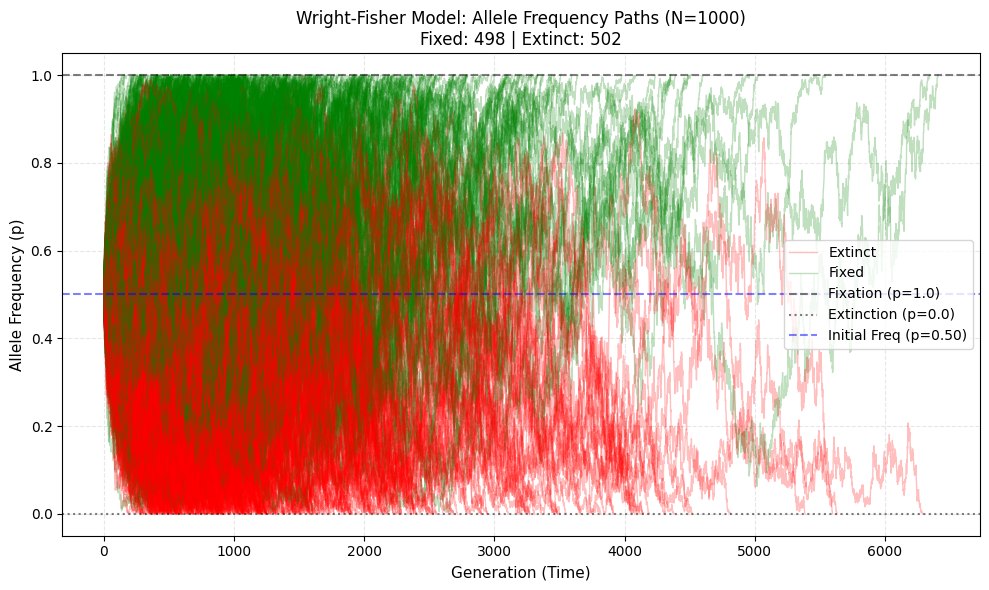

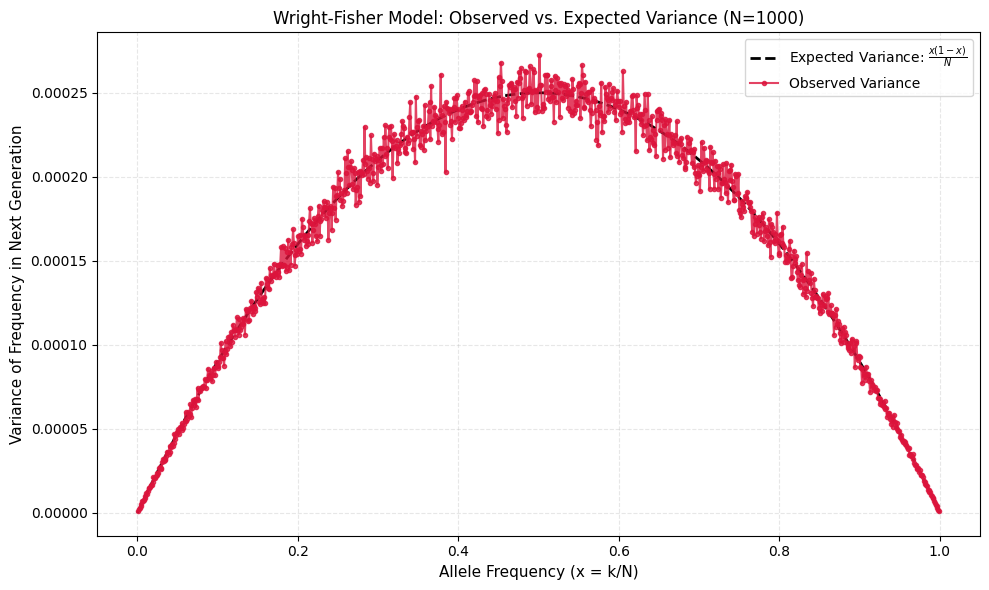

Run 100 of 10000 is done.
Run 200 of 10000 is done.
Run 300 of 10000 is done.
Run 400 of 10000 is done.
Run 500 of 10000 is done.
Run 600 of 10000 is done.
Run 700 of 10000 is done.
Run 800 of 10000 is done.
Run 900 of 10000 is done.
Run 1000 of 10000 is done.
Run 1100 of 10000 is done.
Run 1200 of 10000 is done.
Run 1300 of 10000 is done.
Run 1400 of 10000 is done.
Run 1500 of 10000 is done.
Run 1600 of 10000 is done.
Run 1700 of 10000 is done.
Run 1800 of 10000 is done.
Run 1900 of 10000 is done.
Run 2000 of 10000 is done.
Run 2100 of 10000 is done.
Run 2200 of 10000 is done.
Run 2300 of 10000 is done.
Run 2400 of 10000 is done.
Run 2500 of 10000 is done.
Run 2600 of 10000 is done.
Run 2700 of 10000 is done.
Run 2800 of 10000 is done.
Run 2900 of 10000 is done.
Run 3000 of 10000 is done.
Run 3100 of 10000 is done.
Run 3200 of 10000 is done.
Run 3300 of 10000 is done.
Run 3400 of 10000 is done.
Run 3500 of 10000 is done.
Run 3600 of 10000 is done.
Run 3700 of 10000 is done.
Run 3800 o

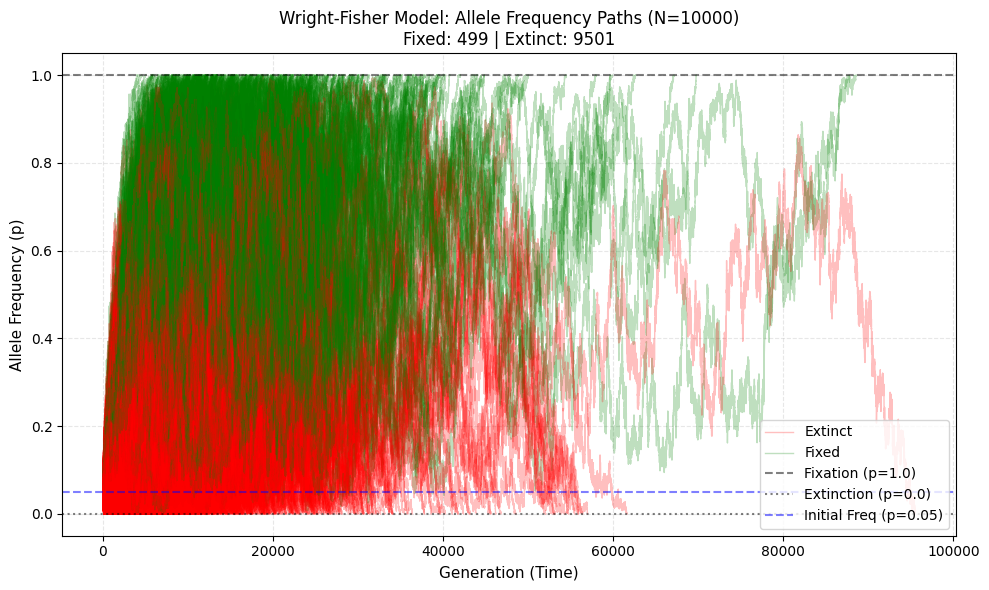

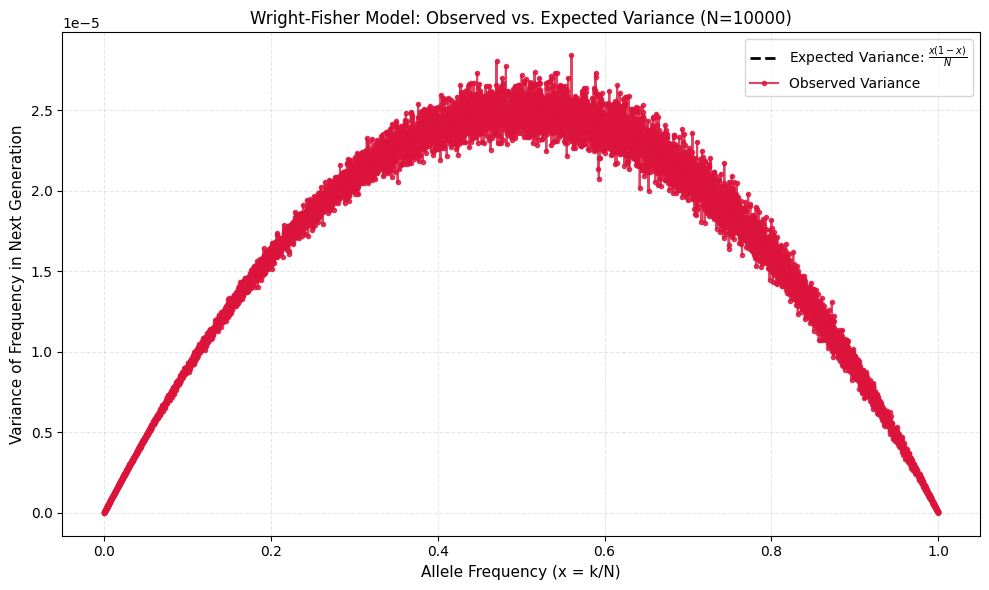

Run 100 of 1000 is done.
Run 200 of 1000 is done.
Run 300 of 1000 is done.
Run 400 of 1000 is done.
Run 500 of 1000 is done.
Run 600 of 1000 is done.
Run 700 of 1000 is done.
Run 800 of 1000 is done.
Run 900 of 1000 is done.
Run 1000 of 1000 is done.

--- Simulation Metrics ---
Average generation time for Fixed alleles: 1587.00 generations
Average generation time for Extinct alleles: 11.34 generations
Total Fixed: 1 | Total Extinct: 999
--------------------------


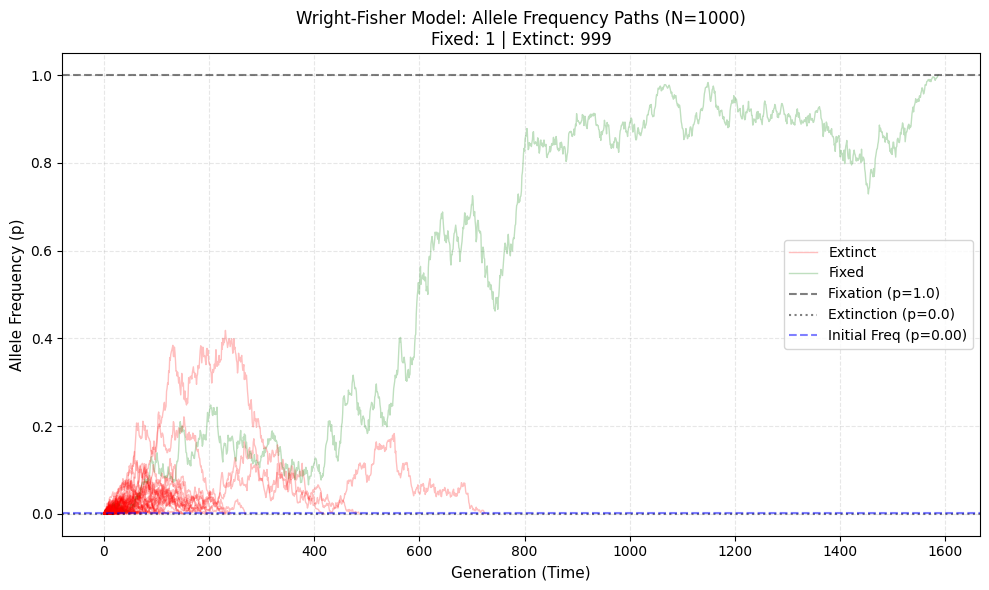

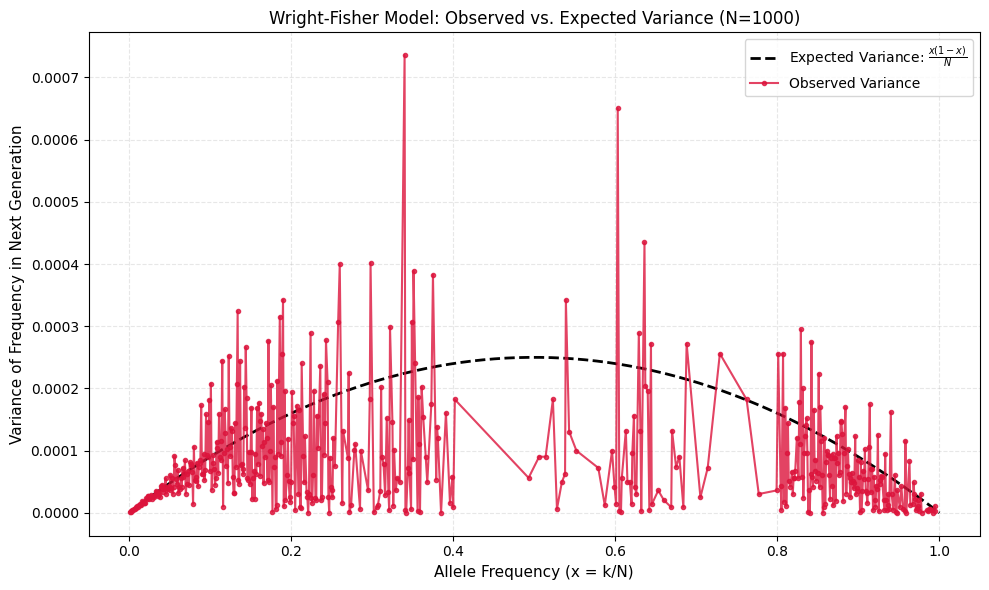

Run 100 of 10000 is done.
Run 200 of 10000 is done.
Run 300 of 10000 is done.
Run 400 of 10000 is done.
Run 500 of 10000 is done.
Run 600 of 10000 is done.
Run 700 of 10000 is done.
Run 800 of 10000 is done.
Run 900 of 10000 is done.
Run 1000 of 10000 is done.
Run 1100 of 10000 is done.
Run 1200 of 10000 is done.
Run 1300 of 10000 is done.
Run 1400 of 10000 is done.
Run 1500 of 10000 is done.
Run 1600 of 10000 is done.
Run 1700 of 10000 is done.
Run 1800 of 10000 is done.
Run 1900 of 10000 is done.
Run 2000 of 10000 is done.
Run 2100 of 10000 is done.
Run 2200 of 10000 is done.
Run 2300 of 10000 is done.
Run 2400 of 10000 is done.
Run 2500 of 10000 is done.
Run 2600 of 10000 is done.
Run 2700 of 10000 is done.
Run 2800 of 10000 is done.
Run 2900 of 10000 is done.
Run 3000 of 10000 is done.
Run 3100 of 10000 is done.
Run 3200 of 10000 is done.
Run 3300 of 10000 is done.
Run 3400 of 10000 is done.
Run 3500 of 10000 is done.
Run 3600 of 10000 is done.
Run 3700 of 10000 is done.
Run 3800 o

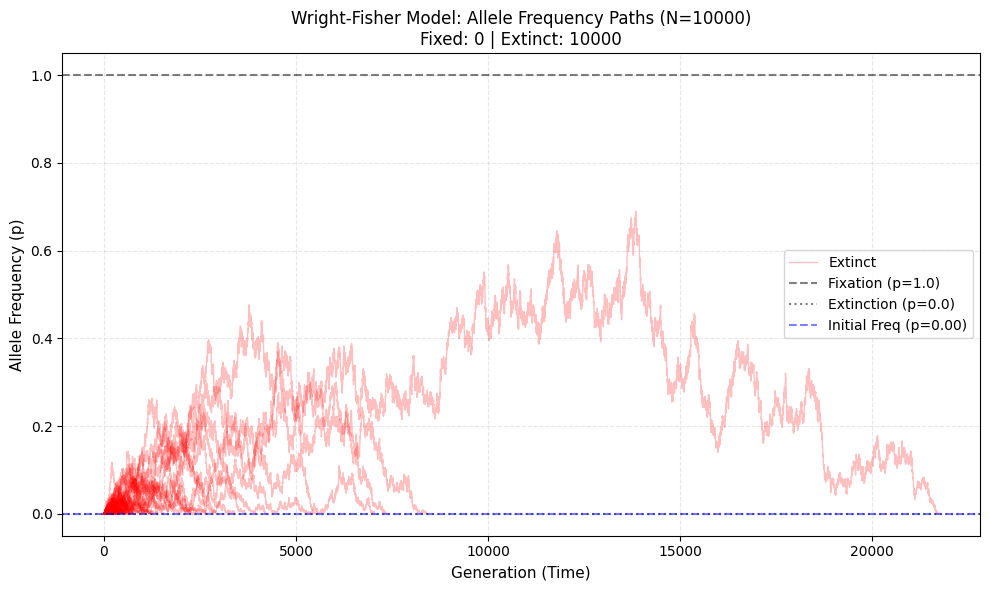

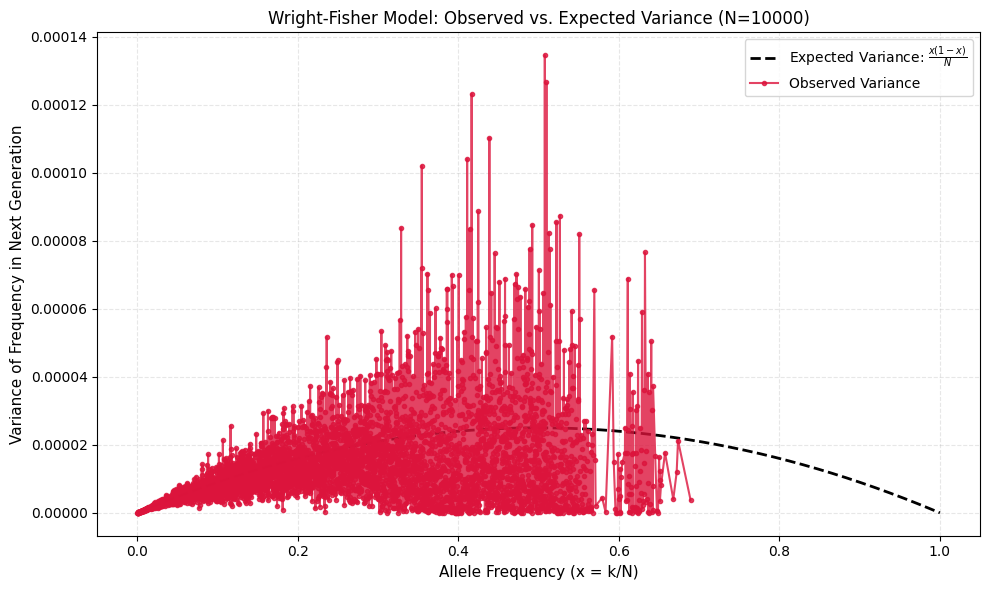

Run 100 of 100 is done.

--- Simulation Metrics ---
Average generation time for Fixed alleles: 283.00 generations
Average generation time for Extinct alleles: 12.31 generations
Total Fixed: 4 | Total Extinct: 96
--------------------------


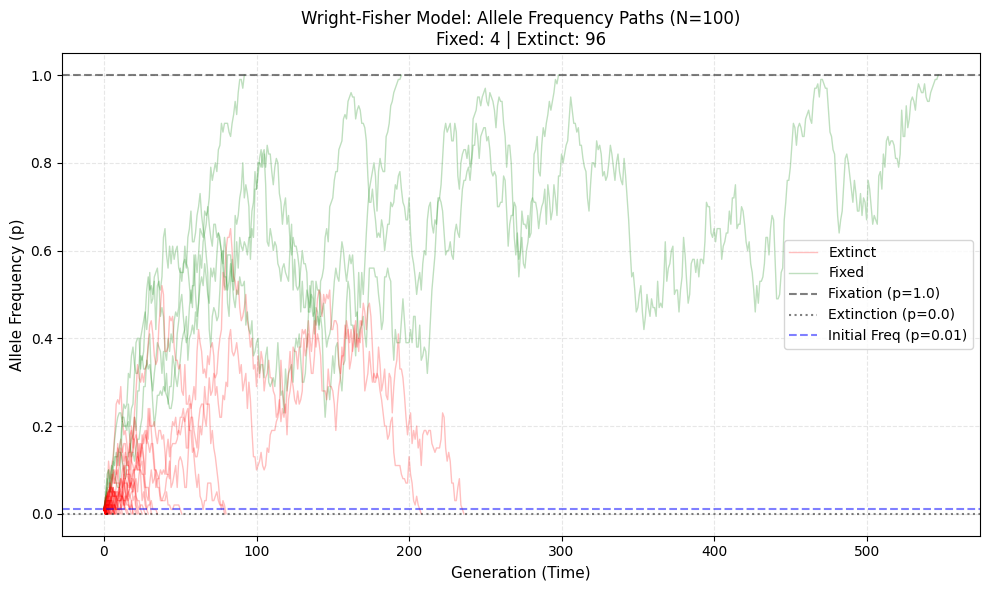

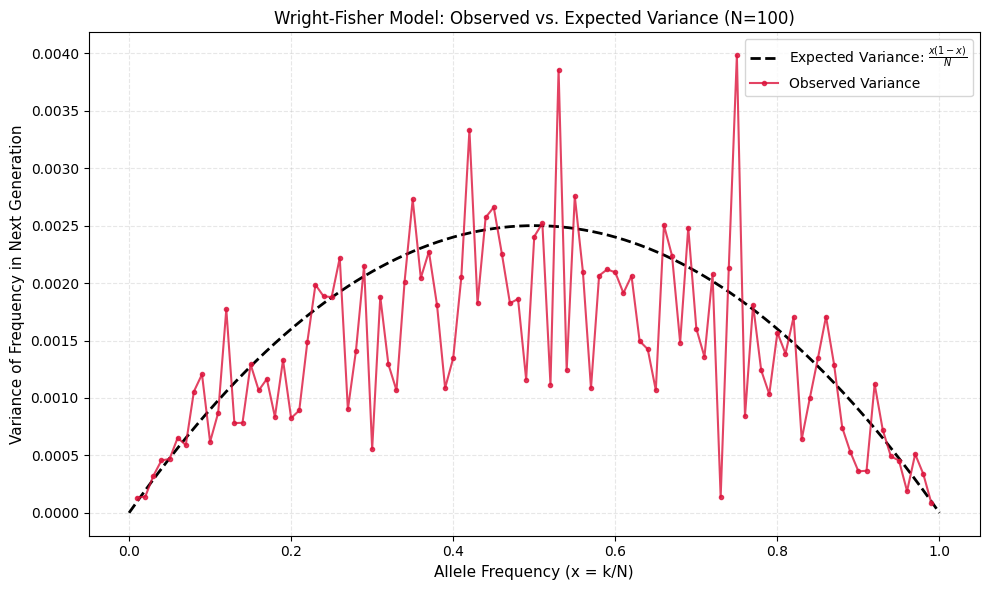

Run 100 of 1000 is done.
Run 200 of 1000 is done.
Run 300 of 1000 is done.
Run 400 of 1000 is done.
Run 500 of 1000 is done.
Run 600 of 1000 is done.
Run 700 of 1000 is done.
Run 800 of 1000 is done.
Run 900 of 1000 is done.
Run 1000 of 1000 is done.

--- Simulation Metrics ---
Average generation time for Fixed alleles: 216.25 generations
Average generation time for Extinct alleles: 9.15 generations
Total Fixed: 8 | Total Extinct: 992
--------------------------


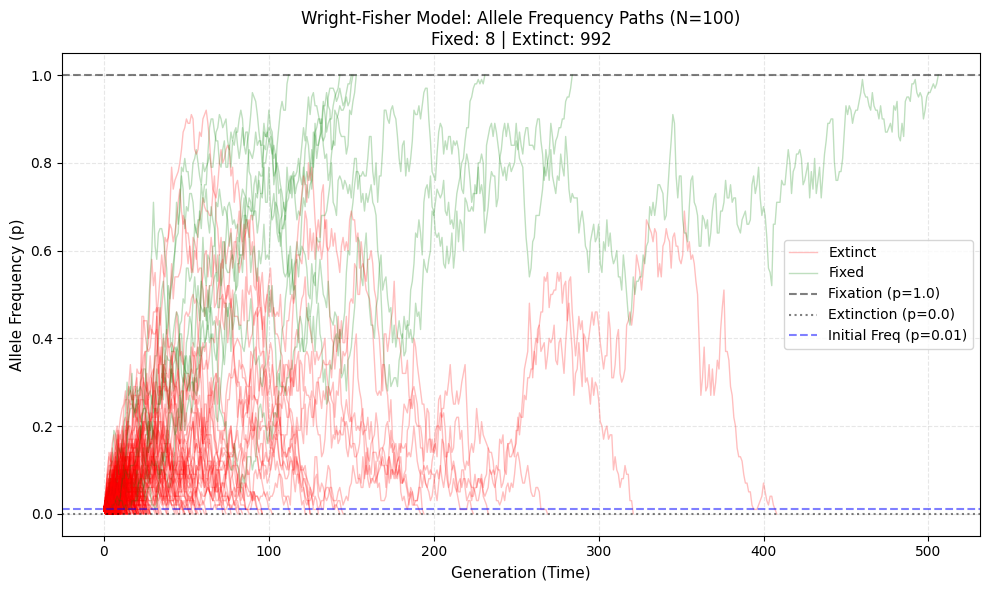

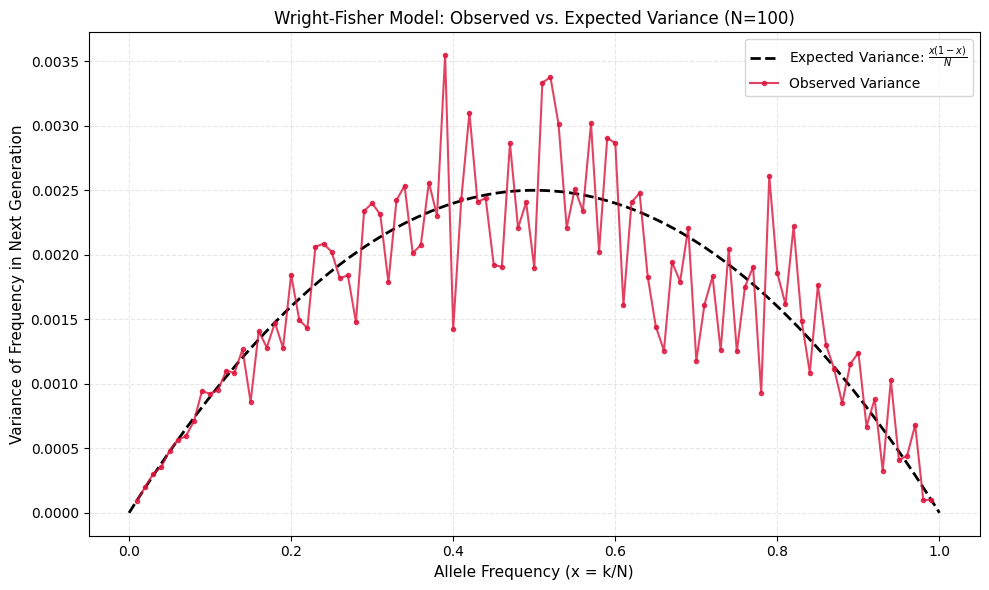

Run 100 of 10000 is done.
Run 200 of 10000 is done.
Run 300 of 10000 is done.
Run 400 of 10000 is done.
Run 500 of 10000 is done.
Run 600 of 10000 is done.
Run 700 of 10000 is done.
Run 800 of 10000 is done.
Run 900 of 10000 is done.
Run 1000 of 10000 is done.
Run 1100 of 10000 is done.
Run 1200 of 10000 is done.
Run 1300 of 10000 is done.
Run 1400 of 10000 is done.
Run 1500 of 10000 is done.
Run 1600 of 10000 is done.
Run 1700 of 10000 is done.
Run 1800 of 10000 is done.
Run 1900 of 10000 is done.
Run 2000 of 10000 is done.
Run 2100 of 10000 is done.
Run 2200 of 10000 is done.
Run 2300 of 10000 is done.
Run 2400 of 10000 is done.
Run 2500 of 10000 is done.
Run 2600 of 10000 is done.
Run 2700 of 10000 is done.
Run 2800 of 10000 is done.
Run 2900 of 10000 is done.
Run 3000 of 10000 is done.
Run 3100 of 10000 is done.
Run 3200 of 10000 is done.
Run 3300 of 10000 is done.
Run 3400 of 10000 is done.
Run 3500 of 10000 is done.
Run 3600 of 10000 is done.
Run 3700 of 10000 is done.
Run 3800 o

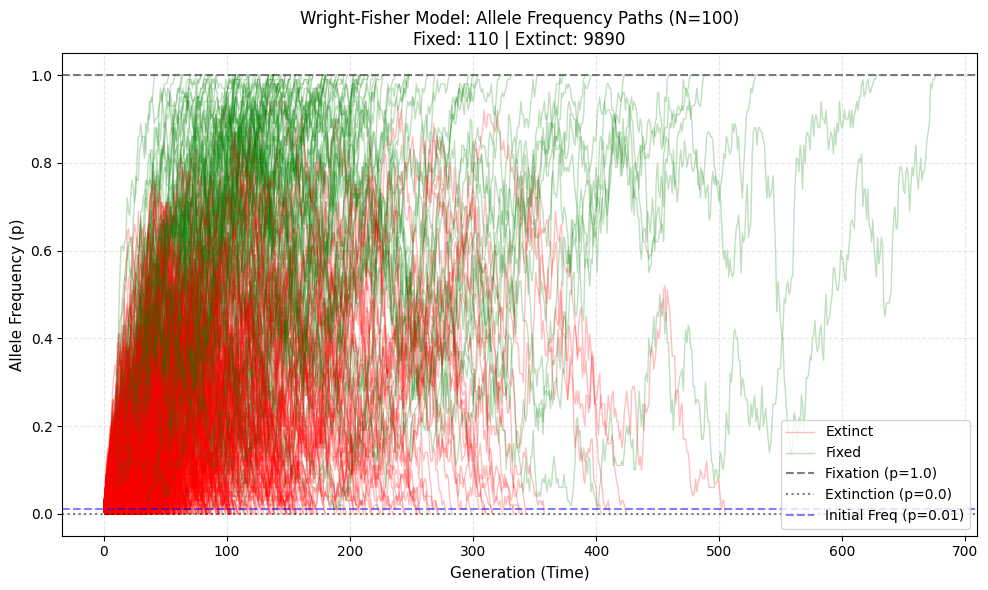

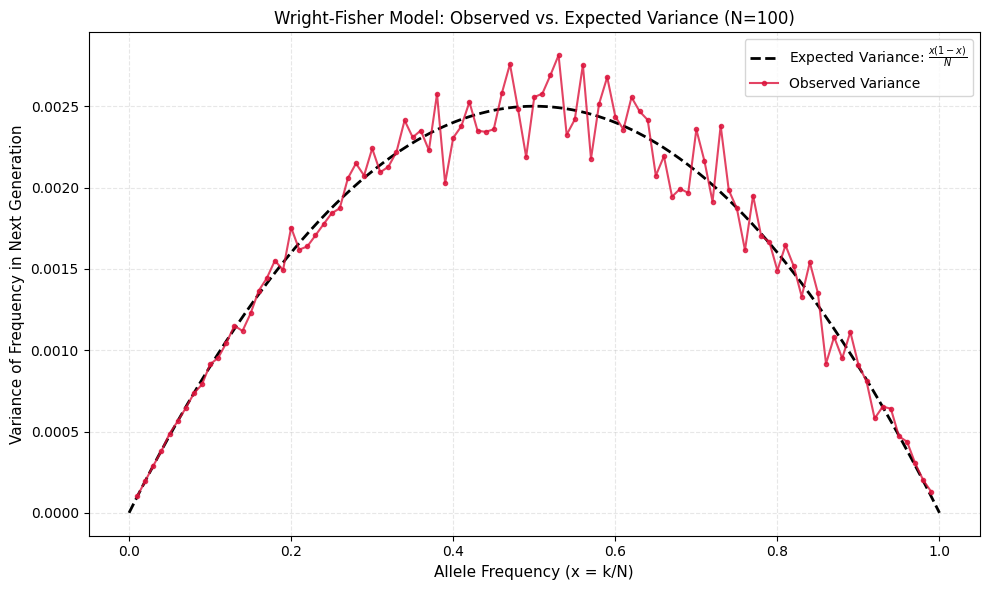

In [5]:
POPULATION_SIZE = 1000  
INITIAL_ALLELES = 500 
NUM_RUNS = 1000

sim_data = run_multiple_simulations(N=POPULATION_SIZE, K=INITIAL_ALLELES, num_simulations=NUM_RUNS)

plot_allele_frequency_paths(sim_data, N=POPULATION_SIZE, K=INITIAL_ALLELES)
plot_observed_vs_expected_variance(sim_data, N=POPULATION_SIZE)

# Display both plots
plt.show()

POPULATION_SIZE = 10000  
INITIAL_ALLELES = 500 
NUM_RUNS = 10000

sim_data = run_multiple_simulations(N=POPULATION_SIZE, K=INITIAL_ALLELES, num_simulations=NUM_RUNS)

plot_allele_frequency_paths(sim_data, N=POPULATION_SIZE, K=INITIAL_ALLELES)
plot_observed_vs_expected_variance(sim_data, N=POPULATION_SIZE)

# Display both plots
plt.show()

POPULATION_SIZE = 1000  
INITIAL_ALLELES = 1 
NUM_RUNS = 1000

sim_data = run_multiple_simulations(N=POPULATION_SIZE, K=INITIAL_ALLELES, num_simulations=NUM_RUNS)

plot_allele_frequency_paths(sim_data, N=POPULATION_SIZE, K=INITIAL_ALLELES)
plot_observed_vs_expected_variance(sim_data, N=POPULATION_SIZE)

# Display both plots
plt.show()

POPULATION_SIZE = 10000  
INITIAL_ALLELES = 1 
NUM_RUNS = 10000

sim_data = run_multiple_simulations(N=POPULATION_SIZE, K=INITIAL_ALLELES, num_simulations=NUM_RUNS)

plot_allele_frequency_paths(sim_data, N=POPULATION_SIZE, K=INITIAL_ALLELES)
plot_observed_vs_expected_variance(sim_data, N=POPULATION_SIZE)

# Display both plots
plt.show()

POPULATION_SIZE = 100  
INITIAL_ALLELES = 1 
NUM_RUNS = 100

sim_data = run_multiple_simulations(N=POPULATION_SIZE, K=INITIAL_ALLELES, num_simulations=NUM_RUNS)

plot_allele_frequency_paths(sim_data, N=POPULATION_SIZE, K=INITIAL_ALLELES)
plot_observed_vs_expected_variance(sim_data, N=POPULATION_SIZE)

# Display both plots
plt.show()

POPULATION_SIZE = 100  
INITIAL_ALLELES = 1 
NUM_RUNS = 1000

sim_data = run_multiple_simulations(N=POPULATION_SIZE, K=INITIAL_ALLELES, num_simulations=NUM_RUNS)

plot_allele_frequency_paths(sim_data, N=POPULATION_SIZE, K=INITIAL_ALLELES)
plot_observed_vs_expected_variance(sim_data, N=POPULATION_SIZE)

# Display both plots
plt.show()

POPULATION_SIZE = 100  
INITIAL_ALLELES = 1 
NUM_RUNS = 10000

sim_data = run_multiple_simulations(N=POPULATION_SIZE, K=INITIAL_ALLELES, num_simulations=NUM_RUNS)

plot_allele_frequency_paths(sim_data, N=POPULATION_SIZE, K=INITIAL_ALLELES)
plot_observed_vs_expected_variance(sim_data, N=POPULATION_SIZE)

# Display both plots
plt.show()